# Phase 2: Temporal Forecasting using LSTM

This notebook focuses on forecasting the evolution of topic proportions over time using a **Long Short-Term Memory (LSTM)** network. We use the topic distributions discovered by BERTopic and aggregate them monthly to create a multivariate time series.

### Goals:
1. Aggregate topic proportions per month.
2. Train a multivariate LSTM to forecast future topic probabilities.
3. Visualize projected trend evolution.

✅ Data loaded: (10000, 19)
Running quick LDA...
✅ dominant_topic created


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 5, 128)         │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,266 (313.54 KB)

 Trainable params: 80,266 (313.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.0131 - val_loss: 0.0098
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0095 - val_loss: 0.0070
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0070 - val_loss: 0.0051
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0060 - val_loss: 0.0042
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0053 - val_loss: 0.0038
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0049 - val_loss: 0.0038
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0052 - val_loss: 0.0038
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0054 - val_loss: 0.0039
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0048 - val_loss: 0.0041
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0046 - val_loss: 0.0045


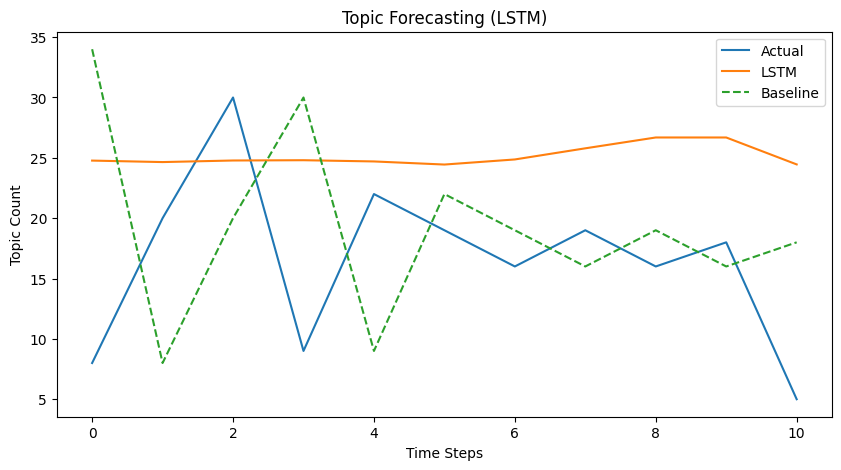

In [45]:
# ==========================================
# 📦 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# 📂 2. Load Data
# ==========================================
df = pd.read_csv('/content/processed_featured_data.csv')

df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['year_month_str'] = df['year_month'].astype(str)

print("✅ Data loaded:", df.shape)


# ==========================================
# 🧠 3. CREATE dominant_topic (LDA FIX)
# ==========================================
print("Running quick LDA...")

vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['clean_text'].fillna(""))

lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

topic_dist = lda.transform(X)
df['dominant_topic'] = topic_dist.argmax(axis=1)

print("✅ dominant_topic created")


# ==========================================
# 📊 4. Create Topic Time-Series
# ==========================================
topic_trends = df.groupby(
    ['year_month_str', 'dominant_topic']
).size().unstack().fillna(0)

topic_trends = topic_trends.sort_index()


# ==========================================
# ✂️ 5. Train-Test Split (FIXED)
# ==========================================
window_size = 5
train_size = int(len(topic_trends) * 0.8)

train = topic_trends.iloc[:train_size]
test = topic_trends.iloc[train_size - window_size:]


# ==========================================
# ⚖️ 6. Scaling
# ==========================================
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


# ==========================================
# 🔁 7. Sequence Creation
# ==========================================
def create_sequences(data, window=5):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)


# ==========================================
# 🧠 8. LSTM Model (BiLSTM)
# ==========================================
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(X_train.shape[2])
])

model.compile(optimizer='adam', loss='mse')

model.summary()


# ==========================================
# 🛑 9. Training
# ==========================================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


# ==========================================
# 🔮 10. Prediction + Inverse Transform
# ==========================================
pred_scaled = model.predict(X_test)
baseline_scaled = X_test[:, -1, :]

pred = scaler.inverse_transform(pred_scaled)
baseline = scaler.inverse_transform(baseline_scaled)
y_test_unscaled = scaler.inverse_transform(y_test)


# ==========================================
# 📊 11. Evaluation
# ==========================================
lstm_mse = mean_squared_error(
    y_test_unscaled.flatten(),
    pred.flatten()
)

baseline_mse = mean_squared_error(
    y_test_unscaled.flatten(),
    baseline.flatten()
)

print(f"\nLSTM MSE: {lstm_mse:.2f}")
print(f"Baseline MSE: {baseline_mse:.2f}")


# ==========================================
# 📈 12. Visualization
# ==========================================
topic_index = 0

plt.figure(figsize=(10,5))
plt.plot(y_test_unscaled[:, topic_index], label="Actual")
plt.plot(pred[:, topic_index], label="LSTM")
plt.plot(baseline[:, topic_index], label="Baseline", linestyle='--')

plt.title("Topic Forecasting (LSTM)")
plt.xlabel("Time Steps")
plt.ylabel("Topic Count")
plt.legend()
plt.show()